In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rc('axes', unicode_minus=False)
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

In [2]:
df_od = pd.read_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\market_od.csv", encoding='utf-8-sig')

## One-Hot Encoding

In [3]:
CAT_COL = "market_item_type"

df_od = pd.get_dummies(
    df_od,
    columns=[CAT_COL],
    drop_first=False,
    dtype = int
)

In [22]:
exclude_cols = [
    '행정기관코드', '시장명', '시도', '시군구', '위도', '경도', '빈점포율', 
    #'점포_대_상인_비율', 
    '총시장상인',
    'pop_t', '지원금액', '지원여부'
]

feature_cols = [c for c in df_od.columns if c not in exclude_cols]


In [23]:
df_train = df_od[feature_cols + ['빈점포율']]

In [24]:
df_od.shape

(833, 62)

In [25]:
df_train.columns, df_train.shape

(Index(['시장면적', '전체점포', '노점수', '편의시설수', '점포_대_상인_비율', 'parking', 'bus', 'mart',
        'tour', 'conv', 'subway', 'pop_adole', 'pop_young', 'pop_middle',
        'pop_senior', 'has_assoc', 'join_stores', 'item_diversity',
        'is_food_based', 'has_nonfood', 'delivery_grocery', 'od_adole',
        'od_young', 'od_middle', 'od_senior', 'od_consumption', 'od_workedu',
        'od_residential', 'od_in_weekday', 'od_in_holiday', 'od_modal_car',
        'od_modal_walk', 'od_modal_bus', 'od_modal_sub', 'od_modal_etc',
        'stay_adole', 'stay_young', 'stay_middle', 'stay_senior',
        'stay_consumption', 'stay_workedu', 'stay_residential', 'stay_weekday',
        'stay_holiday', 'stay_morning', 'stay_lunch', 'stay_evening',
        'stay_night', 'market_item_type_먹거리/외식형',
        'market_item_type_복합형(생활+비식품)', 'market_item_type_비식품/전문형',
        'market_item_type_생활형(장보기형)', 'market_item_type_서비스형', '빈점포율'],
       dtype='object'),
 (833, 54))

## 산점도

In [26]:
TARGET = '빈점포율'

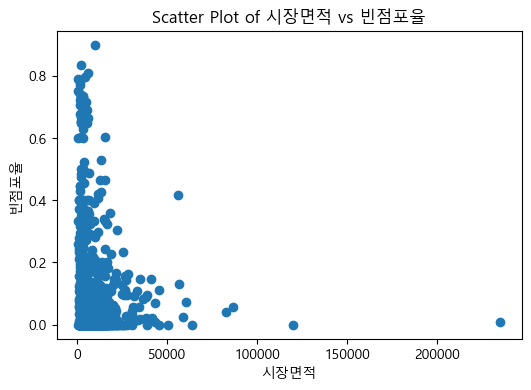

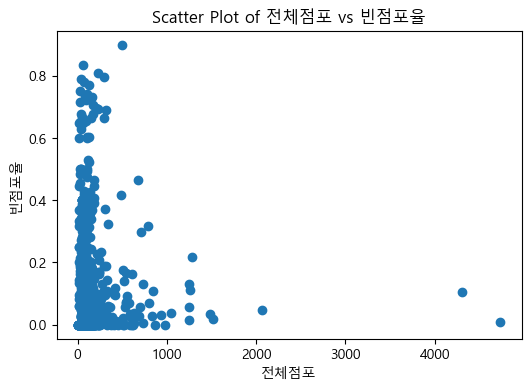

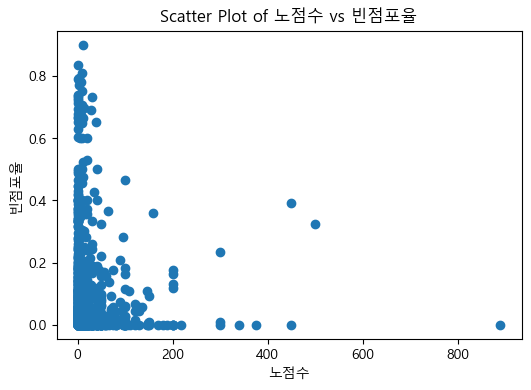

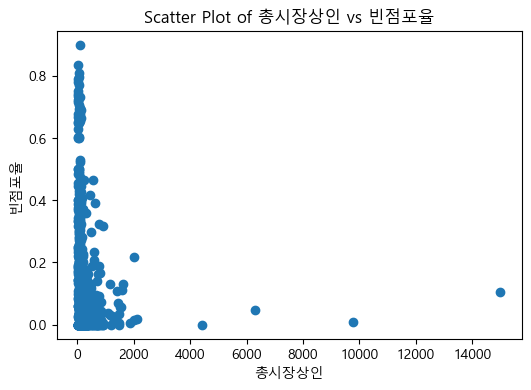

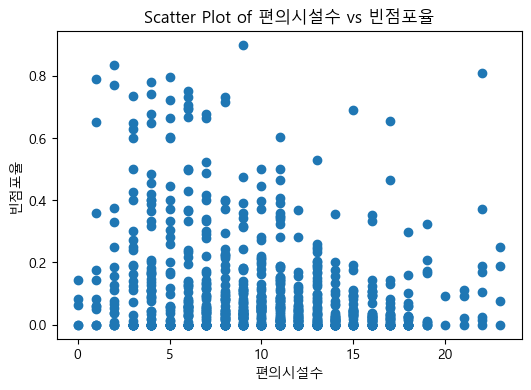

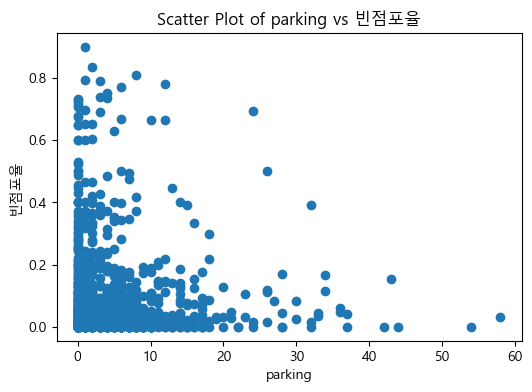

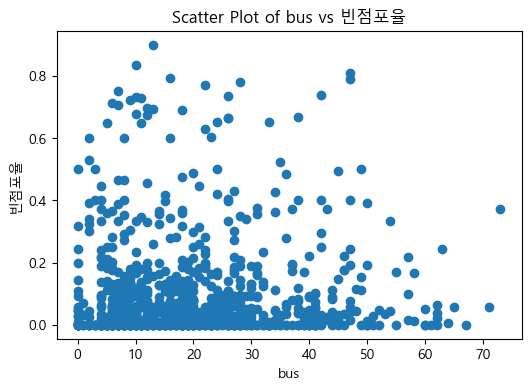

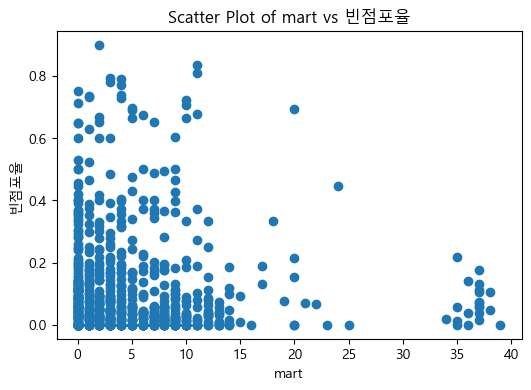

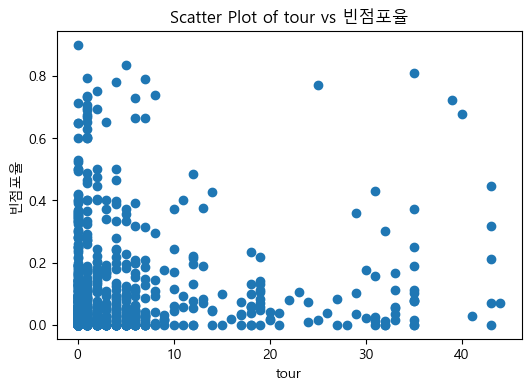

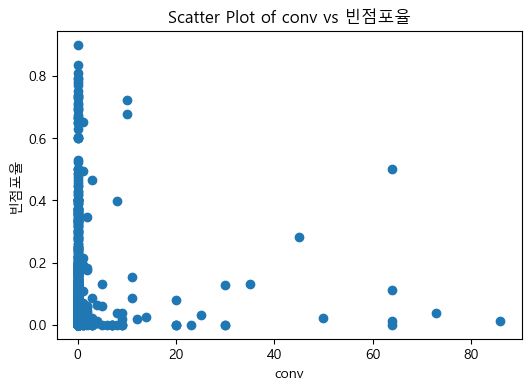

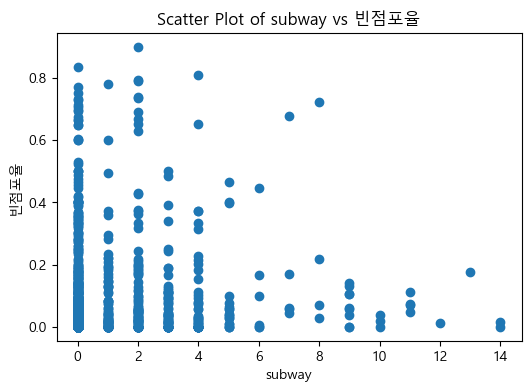

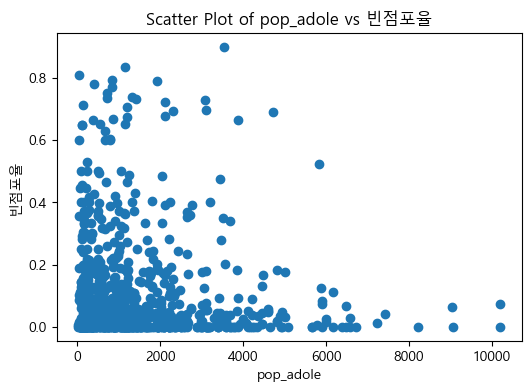

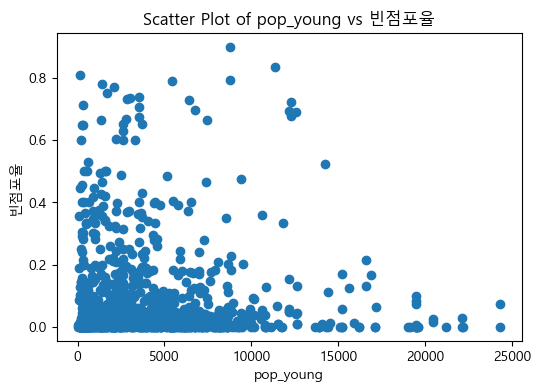

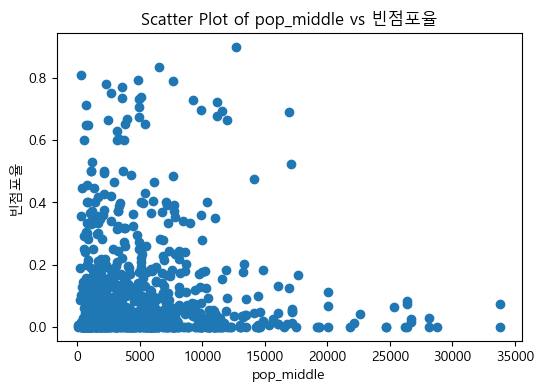

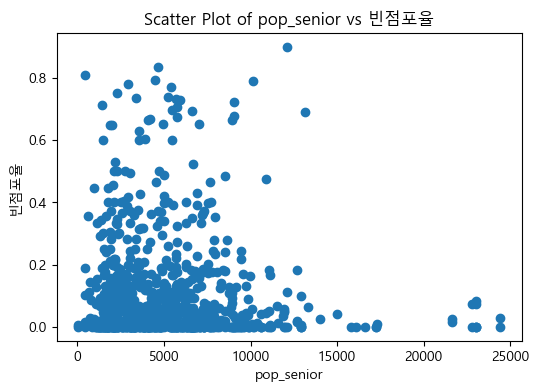

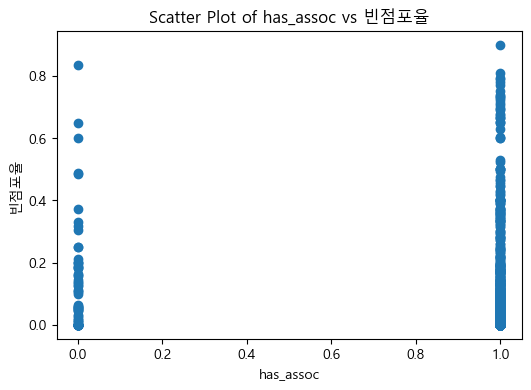

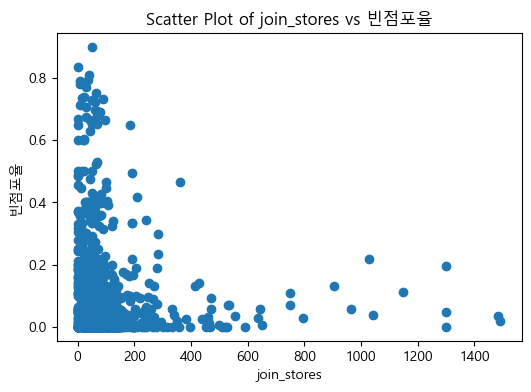

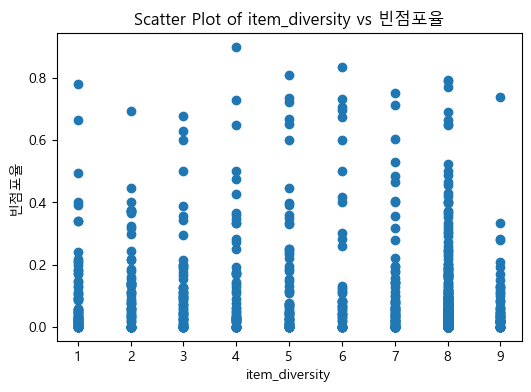

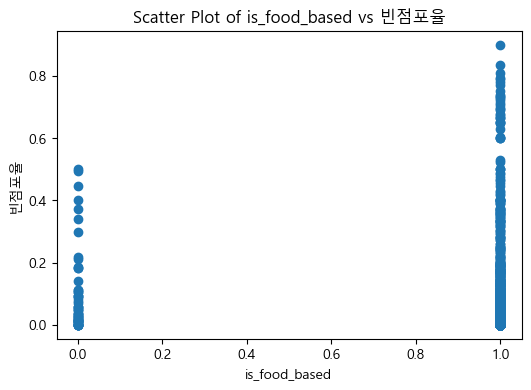

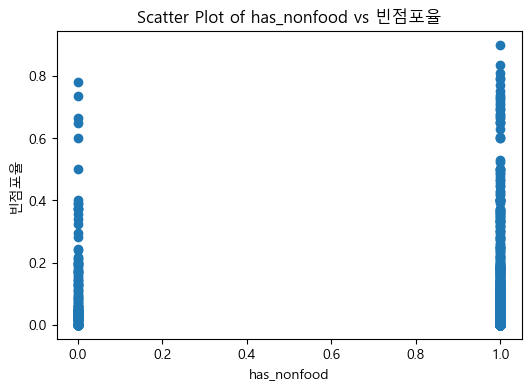

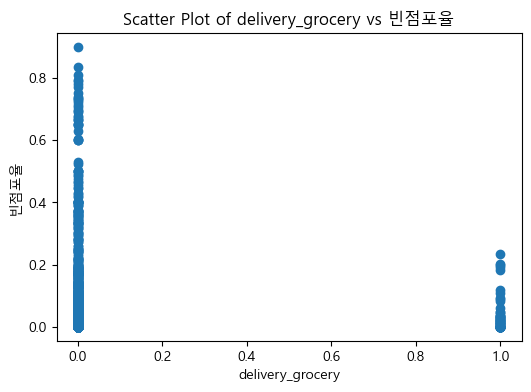

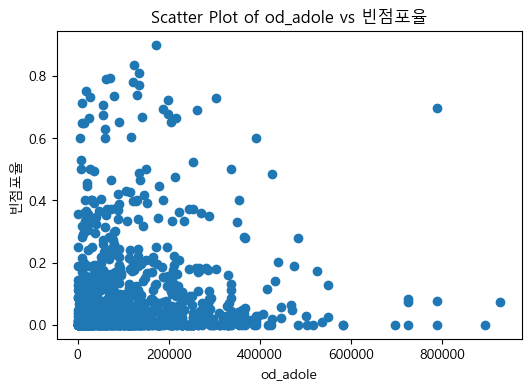

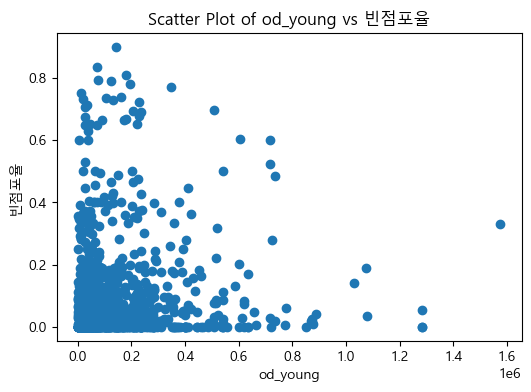

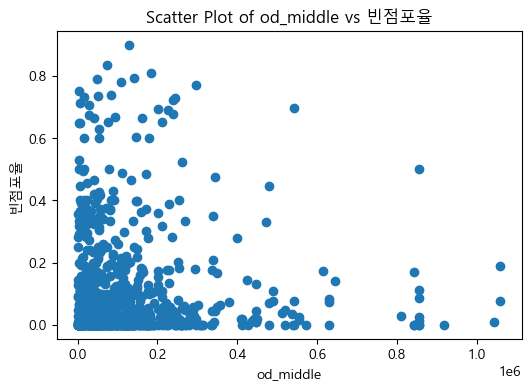

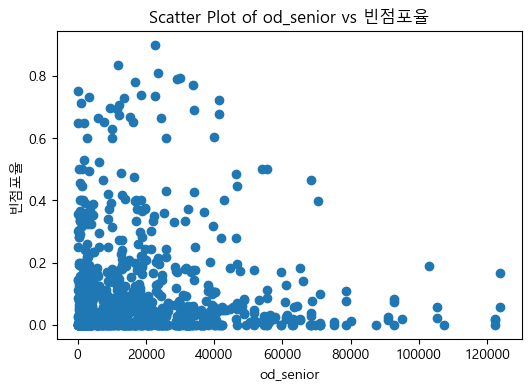

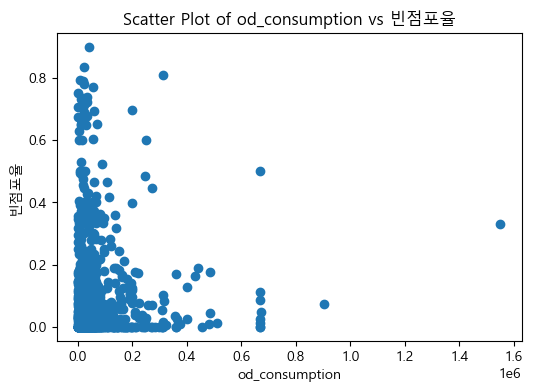

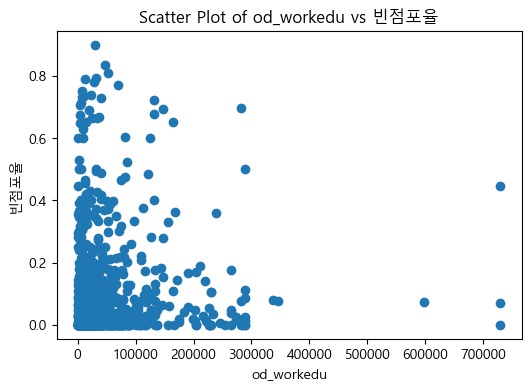

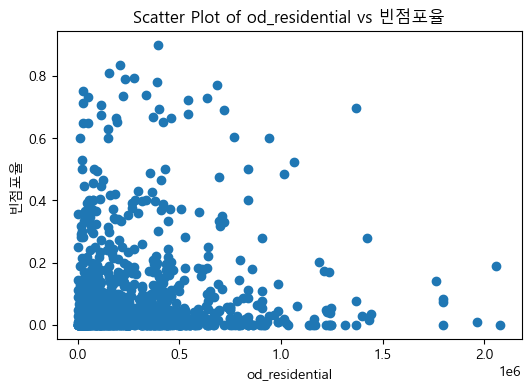

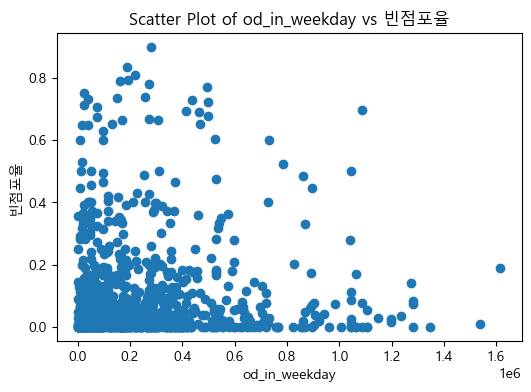

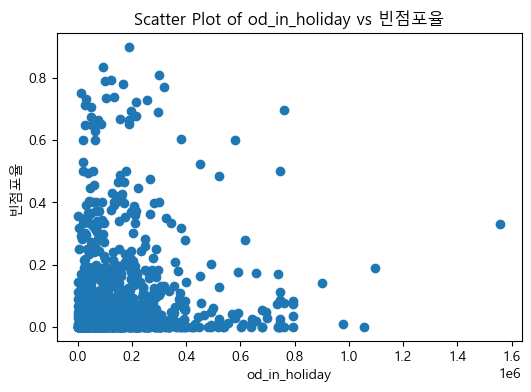

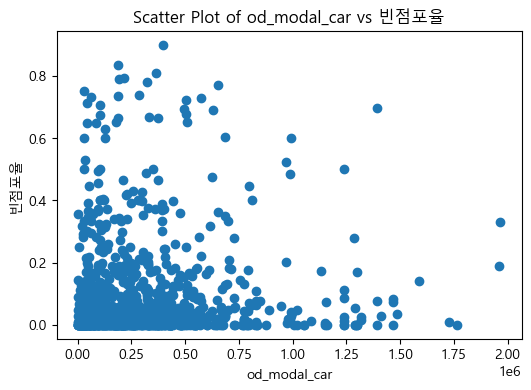

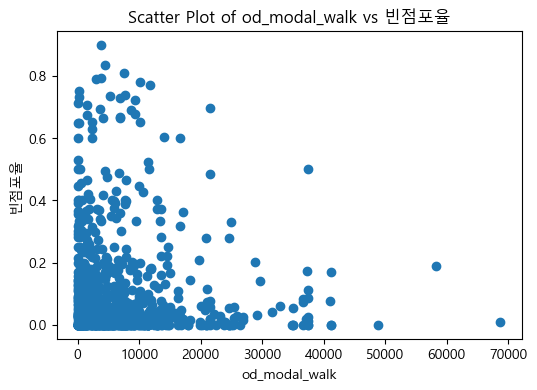

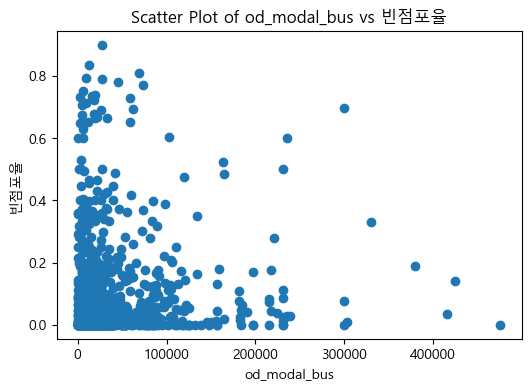

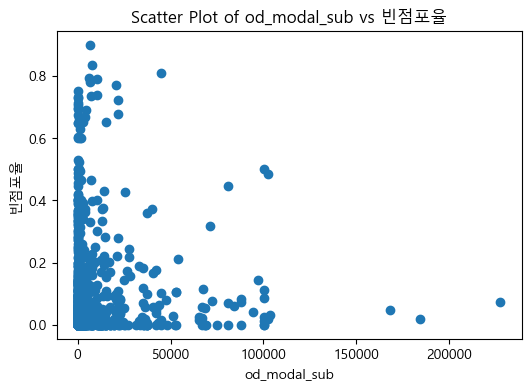

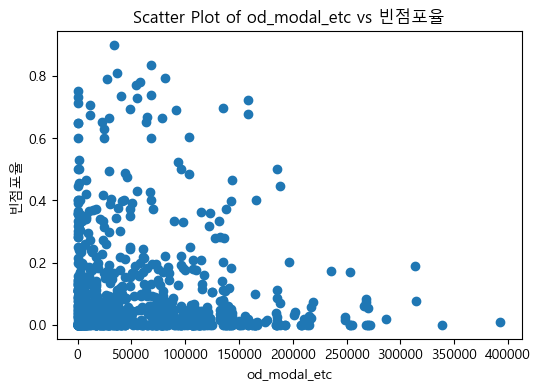

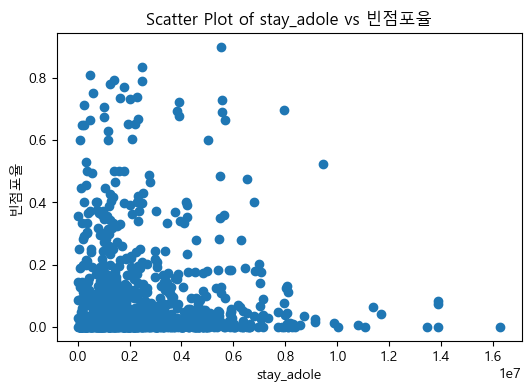

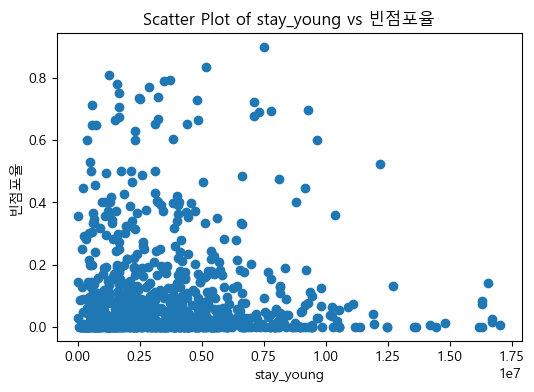

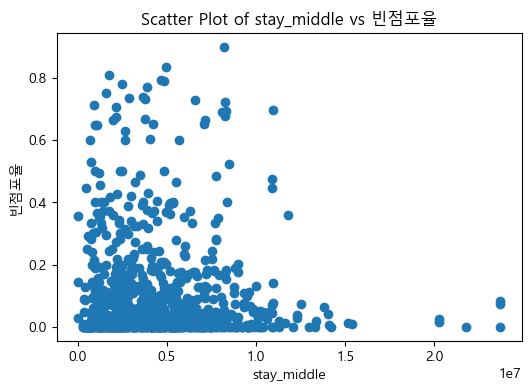

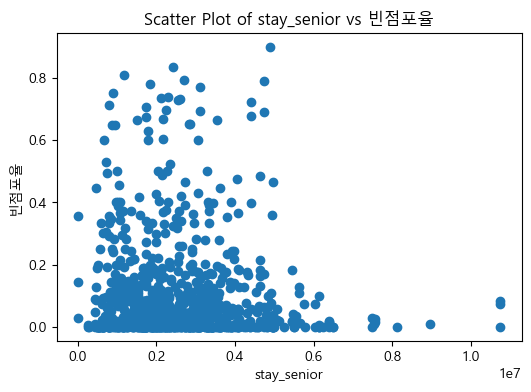

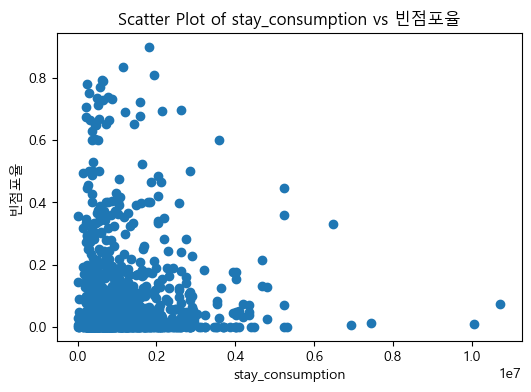

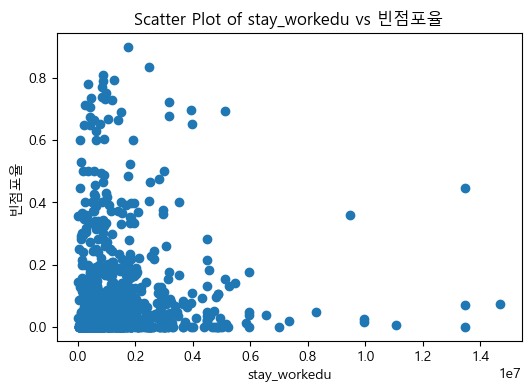

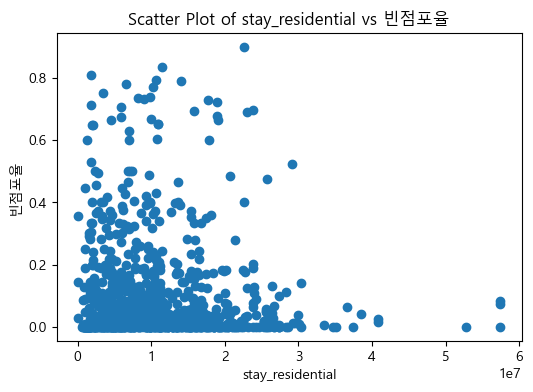

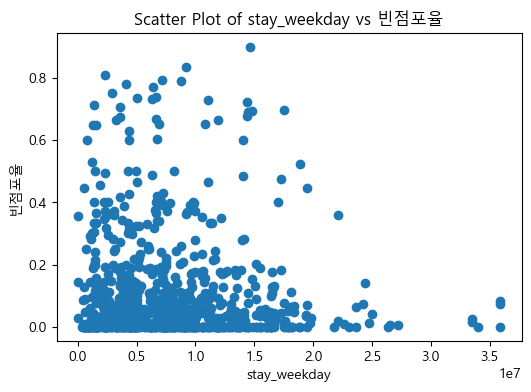

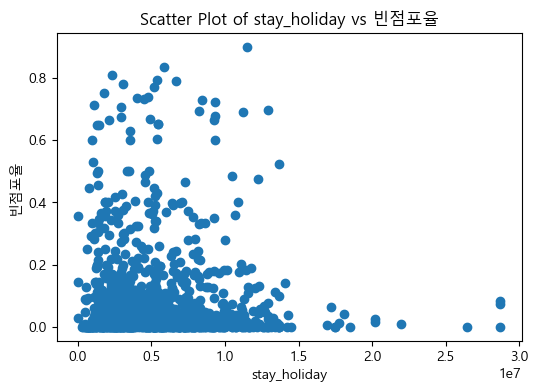

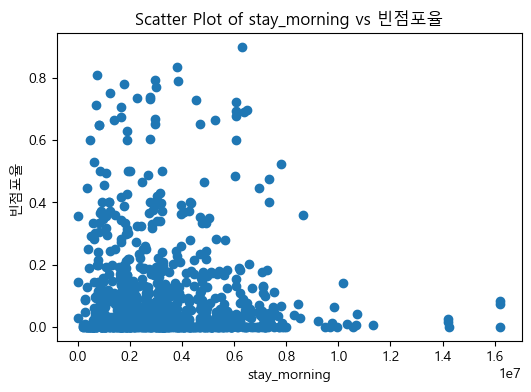

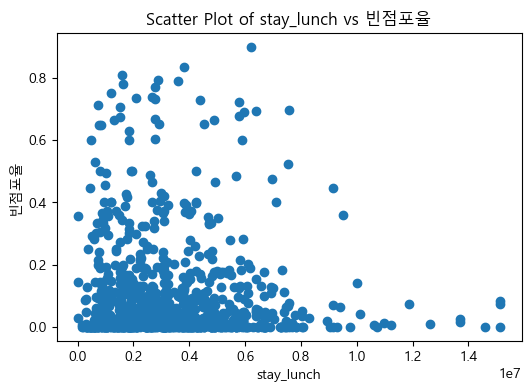

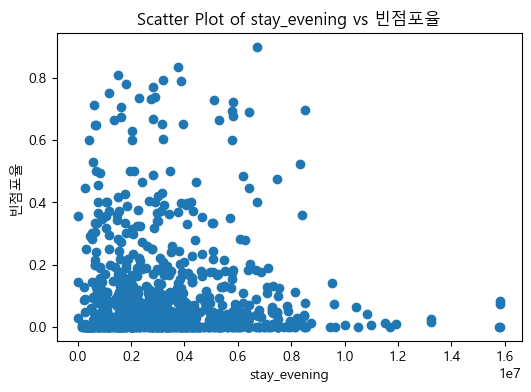

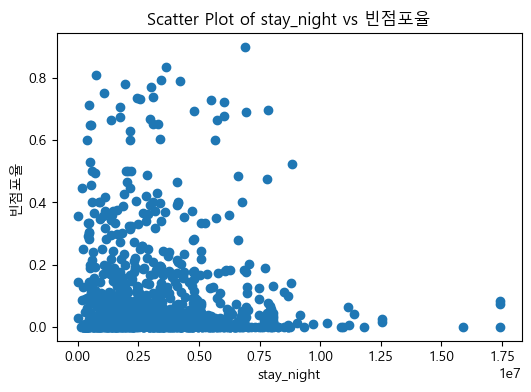

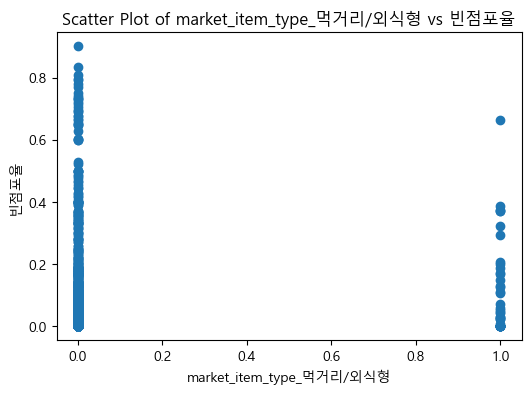

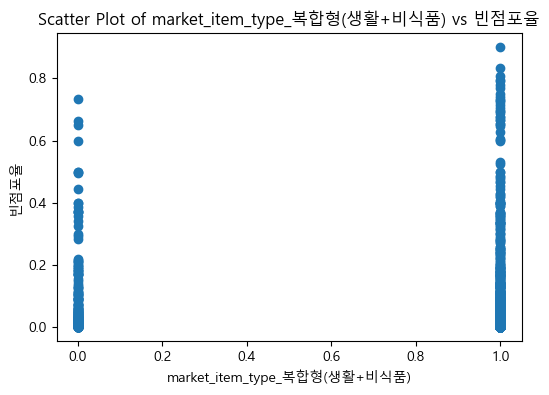

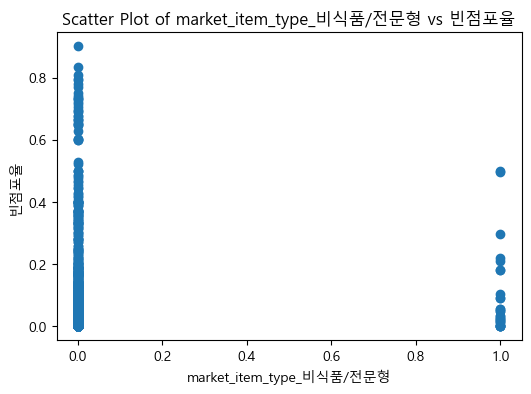

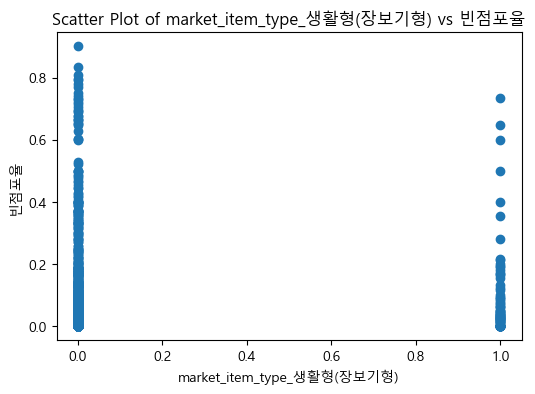

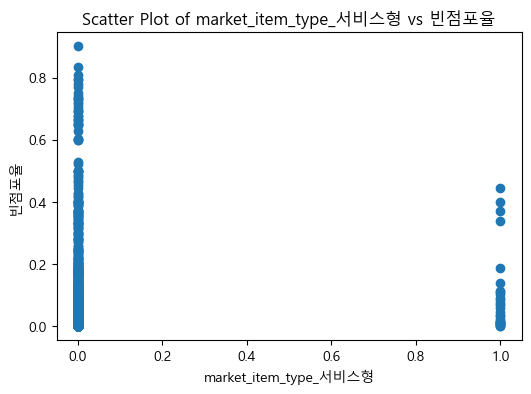

In [ ]:
# 나머지 변수들에 대한 산점도를 반복적으로 그리기
for column in feature_cols:
    if column != TARGET:
        plt.figure(figsize=(6, 4))  # 각 산점도를 적당한 크기로 설정
        plt.scatter(df_train[column], df_train[TARGET])
        plt.xlabel(column)
        plt.ylabel(TARGET)
        plt.title(f'Scatter Plot of {column} vs {TARGET}')
        plt.show()

## Feature Selection

### Spearman

In [27]:
spearman_corr = df_train.corr(method='spearman')

print(spearman_corr[TARGET].abs().sort_values(ascending=False))

빈점포율                            1.000000
점포_대_상인_비율                      0.235047
delivery_grocery                0.193704
편의시설수                           0.175194
시장면적                            0.173486
join_stores                     0.141506
노점수                             0.139724
pop_young                       0.118864
tour                            0.107006
pop_middle                      0.103409
pop_adole                       0.092085
item_diversity                  0.089666
stay_residential                0.083070
stay_night                      0.083019
stay_holiday                    0.081784
bus                             0.080649
pop_senior                      0.077745
stay_evening                    0.072804
market_item_type_생활형(장보기형)      0.072259
stay_morning                    0.070755
stay_adole                      0.070712
stay_weekday                    0.069698
stay_lunch                      0.067733
stay_senior                     0.067560
stay_young      

### Feature Importance

In [28]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

def get_top_features_tree_models(
    df,
    target_col,
    n_top=15,
    random_state=123
):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    models = {
        "DecisionTree": DecisionTreeRegressor(random_state=random_state),
        "RandomForest": RandomForestRegressor(random_state=random_state),
        "XGBoost": XGBRegressor(random_state=random_state),
        "LGBM": LGBMRegressor(random_state=random_state)
    }

    results = {}

    for name, model in models.items():
        model.fit(X, y)

        importances = model.feature_importances_
        fi_df = (
            pd.DataFrame({
                "Feature": X.columns,
                "Importance": importances
            })
            .sort_values("Importance", ascending=False)
            .head(n_top)
            .reset_index(drop=True)
        )

        results[name] = fi_df
        print(f"\n[{name}] 상위 {n_top}개 변수")
        print(list(fi_df["Feature"]))

    return results


In [29]:
TARGET = '빈점포율'

fi_results = get_top_features_tree_models(
    df=df_train,
    target_col=TARGET,
    n_top=15
)



[DecisionTree] 상위 15개 변수
['전체점포', 'join_stores', '시장면적', '편의시설수', '노점수', 'od_modal_bus', 'stay_consumption', 'pop_senior', 'bus', '점포_대_상인_비율', 'stay_workedu', 'od_senior', 'od_consumption', 'od_young', 'od_modal_sub']

[RandomForest] 상위 15개 변수
['전체점포', '시장면적', 'join_stores', '편의시설수', '점포_대_상인_비율', 'bus', 'stay_consumption', 'pop_young', 'tour', '노점수', 'od_consumption', 'pop_senior', 'od_senior', 'od_young', 'od_modal_bus']

[XGBoost] 상위 15개 변수
['편의시설수', 'join_stores', 'stay_adole', '전체점포', 'pop_senior', 'stay_senior', 'od_modal_bus', 'stay_consumption', 'stay_morning', 'pop_middle', 'stay_night', 'stay_weekday', 'od_modal_etc', 'od_middle', 'market_item_type_생활형(장보기형)']
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000502 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8949
[LightGBM] [Info] Number of data points in the train set: 833, number of used features: 53
[LightGBM] [Info] Start training

In [30]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

TARGET = "빈점포율"

X = df_train.drop(columns=[TARGET])
y = df_train[TARGET]

# 필요 시 더미 변환
X = pd.get_dummies(X, drop_first=True)

### STEPWISE

In [31]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

k_features = 15
cv = 5
scoring = "neg_mean_absolute_error"
n_jobs = -1
random_state = 123

def run_sfs(model, X, y, name, mode="stepwise", k_features=15, cv=5,
            scoring="neg_mean_absolute_error", n_jobs=-1):
    
    # mode:
    # "fw": Forward Selection
    # "bw": Backward Selection
    # "stepwise": Stepwise-like (SFFS: forward + floating)

    mode = mode.lower()
    if mode not in ["fw", "bw", "stepwise"]:
        raise ValueError("mode must be one of ['fw', 'bw', 'stepwise']")

    if mode == "fw":
        forward, floating = True, False
    elif mode == "bw":
        forward, floating = False, False
    else:  # stepwise
        forward, floating = True, True

    sfs = SFS(
        model,
        k_features=k_features,
        forward=forward,
        floating=floating,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs
    )
    sfs.fit(X.values, y.values)

    selected_idx = list(sfs.k_feature_idx_)
    selected_cols = X.columns[selected_idx].tolist()
    print(f"[{name} | {mode.upper()}] 선택 변수:", selected_cols)
    print(f"[{name} | {mode.upper()}] CV MAE:", -sfs.k_score_)  # scoring이 neg_MAE라서 부호 반전

    return selected_cols, sfs


def run_fw(model, X, y, name, **kwargs):
    return run_sfs(model, X, y, name, mode="fw", **kwargs)

def run_bw(model, X, y, name, **kwargs):
    return run_sfs(model, X, y, name, mode="bw", **kwargs)

def run_stepwise(model, X, y, name, **kwargs):
    return run_sfs(model, X, y, name, mode="stepwise", **kwargs)

In [32]:
# Decision Tree
dt = DecisionTreeRegressor(random_state=random_state)
#selected_cols_dt_fw, sfs_dt_fw = run_fw(dt, X, y, "DT", k_features=12, cv=5)
#selected_cols_dt_bw, sfs_dt_bw = run_bw(dt, X, y, "DT", k_features=12, cv=5)
selected_cols_dt_sw, sfs_dt_sw = run_stepwise(dt, X, y, "DT", k_features=15, cv=3)

[DT | STEPWISE] 선택 변수: ['노점수', 'conv', 'subway', 'pop_middle', 'has_assoc', 'item_diversity', 'is_food_based', 'has_nonfood', 'delivery_grocery', 'stay_weekday', 'market_item_type_먹거리/외식형', 'market_item_type_복합형(생활+비식품)', 'market_item_type_비식품/전문형', 'market_item_type_생활형(장보기형)', 'market_item_type_서비스형']
[DT | STEPWISE] CV MAE: 0.13481406450293112


In [33]:
# Random Forest
rf = RandomForestRegressor(
    random_state=random_state
)
#selected_cols_rf_fw, sfs_rf_fw = run_fw(rf, X, y, "RF", k_features=15, cv=5)
#selected_cols_rf_bw, sfs_rf_bw = run_bw(rf, X, y, "RF", k_features=15, cv=5)
selected_cols_rf_sw, sfs_rf_sw = run_stepwise(rf, X, y, "RF", k_features=15, cv=3)

[RF | STEPWISE] 선택 변수: ['시장면적', '전체점포', '편의시설수', 'conv', 'subway', 'has_assoc', 'join_stores', 'is_food_based', 'has_nonfood', 'stay_consumption', 'market_item_type_먹거리/외식형', 'market_item_type_복합형(생활+비식품)', 'market_item_type_비식품/전문형', 'market_item_type_생활형(장보기형)', 'market_item_type_서비스형']
[RF | STEPWISE] CV MAE: 0.09878920905754464


In [34]:
# XGBoost
xgb = XGBRegressor(
    random_state=random_state
)
#selected_cols_xgb_fw, sfs_xgb_fw = run_fw(xgb, X, y, "XGB", k_features=15, cv=5)
#selected_cols_xgb_bw, sfs_xgb_bw = run_bw(xgb, X, y, "XGB", k_features=15, cv=5)
selected_cols_xgb_sw, sfs_xgb_sw = run_stepwise(xgb, X, y, "XGB", k_features=15, cv=3)

[XGB | STEPWISE] 선택 변수: ['시장면적', '전체점포', '노점수', '편의시설수', 'conv', 'has_assoc', 'join_stores', 'is_food_based', 'delivery_grocery', 'od_adole', 'od_senior', 'market_item_type_복합형(생활+비식품)', 'market_item_type_비식품/전문형', 'market_item_type_생활형(장보기형)', 'market_item_type_서비스형']
[XGB | STEPWISE] CV MAE: 0.10004971981009476


In [35]:
lgbm = LGBMRegressor(
    random_state=random_state
)
#selected_cols_xgb_fw, sfs_xgb_fw = run_fw(lgbm, X, y, "LGBM", k_features=15, cv=5)
#selected_cols_xgb_bw, sfs_xgb_bw = run_bw(lgbm, X, y, "LGBM", k_features=15, cv=5)
selected_cols_lgbm_sw, sfs_lgbm_sw = run_stepwise(lgbm, X, y, "LGBM", k_features=15, cv=3)

[LGBM | STEPWISE] 선택 변수: ['시장면적', '전체점포', '편의시설수', '점포_대_상인_비율', 'has_assoc', 'join_stores', 'item_diversity', 'has_nonfood', 'delivery_grocery', 'od_modal_walk', 'od_modal_etc', 'stay_lunch', 'market_item_type_먹거리/외식형', 'market_item_type_비식품/전문형', 'market_item_type_서비스형']
[LGBM | STEPWISE] CV MAE: 0.09783571842301052


### SELECT

In [36]:
cor_ft = spearman_corr[TARGET].abs().sort_values(ascending=False)[1:16].index.tolist()
fi_dt_ft = fi_results['DecisionTree']['Feature'].tolist()
fi_rf_ft = fi_results['RandomForest']['Feature'].tolist()
fi_xgb_ft = fi_results['XGBoost']['Feature'].tolist()
#fw_dt_ft = selected_cols_dt_fw 
#bw_dt_ft = selected_cols_dt_bw 
sw_dt_ft = selected_cols_dt_sw
#fw_rf_ft = selected_cols_rf_fw 
#bw_rf_ft = selected_cols_rf_bw 
sw_rf_ft = selected_cols_rf_sw
#fw_xgb_ft = selected_cols_xgb_fw 
#bw_xgb_ft = selected_cols_xgb_bw 
sw_xgb_ft = selected_cols_xgb_sw
#fw_lgbm_ft = selected_cols_lgbm_fw 
#bw_lgbm_ft = selected_cols_lgbm_bw 
sw_lgbm_ft = selected_cols_lgbm_sw

In [37]:
from collections import Counter 
ft_counts = cor_ft + fi_dt_ft + fi_rf_ft + fi_xgb_ft + sw_dt_ft + sw_rf_ft + sw_xgb_ft + sw_lgbm_ft

counted_ft = Counter(ft_counts) 
sorted_ft = counted_ft.most_common() 
for feature, count in sorted_ft[:15]: 
    print(f"{feature}: {count}")

편의시설수: 7
join_stores: 7
시장면적: 6
전체점포: 6
노점수: 5
점포_대_상인_비율: 4
delivery_grocery: 4
stay_consumption: 4
market_item_type_생활형(장보기형): 4
has_assoc: 4
market_item_type_비식품/전문형: 4
market_item_type_서비스형: 4
pop_middle: 3
item_diversity: 3
bus: 3


In [20]:
from collections import Counter 
ft_counts = cor_ft + fi_dt_ft + fi_rf_ft + fi_xgb_ft + sw_dt_ft + sw_rf_ft + sw_xgb_ft + sw_lgbm_ft

counted_ft = Counter(ft_counts) 
sorted_ft = counted_ft.most_common() 
for feature, count in sorted_ft[:15]: 
    print(f"{feature}: {count}")

총시장상인: 7
join_stores: 7
노점수: 7
전체점포: 6
delivery_grocery: 5
편의시설수: 5
market_item_type_생활형(장보기형): 5
bus: 4
od_senior: 4
market_item_type_비식품/전문형: 4
market_item_type_서비스형: 4
시장면적: 3
pop_young: 3
tour: 3
item_diversity: 3


## Model

In [38]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

TARGET = "빈점포율"

selected_ft_lists = [x[0] for x in sorted_ft][:15]


X = df_train[selected_ft_lists].copy()
y = df_train[TARGET].copy()

In [39]:
def oof_eval_regression(
    X: pd.DataFrame,
    y: pd.Series,
    model,
    n_splits: int = 5,
    random_state: int = 123
):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof = np.zeros(len(y), dtype=float)

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        m = model
        m.fit(X_tr, y_tr)
        oof[va_idx] = m.predict(X_va)

    mae = mean_absolute_error(y, oof)
    rmse = np.sqrt(mean_squared_error(y, oof))
    r2 = r2_score(y, oof)

    return {"MAE": mae, "RMSE": rmse, "R2": r2, "oof_pred": oof}

In [40]:
models = {
    "DT": DecisionTreeRegressor(
        random_state=random_state
    ),
    "RF": RandomForestRegressor(
        random_state=random_state,
        n_estimators=300,
        max_depth=None,
        n_jobs=1
    ),
    "XGB": XGBRegressor(
        random_state=random_state,
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=1
    ),
    "LGBM": LGBMRegressor(
        random_state=random_state,
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8
    ),
}


In [41]:
results = {}
rows = []

for name, model in models.items():
    out = oof_eval_regression(X, y, model, n_splits=5, random_state=123)
    results[name] = out
    rows.append({"Model": name, "MAE": out["MAE"], "RMSE": out["RMSE"], "R2": out["R2"]})

score_df = pd.DataFrame(rows).sort_values("MAE")
print(score_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000177 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1299
[LightGBM] [Info] Number of data points in the train set: 666, number of used features: 15
[LightGBM] [Info] Start training from score 0.105306
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [47]:
# LGBM 모델 선정
df_train_oof = df_train.copy()
df_train_oof["oof_LGBM"] = results["LGBM"]["oof_pred"]
df_train_oof = df_train_oof.rename(columns = {'oof_LGBM': 'pred'})

In [188]:
df_train_oof.head(3)

,시장면적,전체점포,노점수,점포상인,종업원,노점상인,편의시설수,총시장상인,pop_adole,pop_young,...,stay_lunch,stay_evening,stay_night,market_item_type_0,market_item_type_1,market_item_type_2,market_item_type_3,market_item_type_4,빈점포율,pred
0,6628,83,49,83,59,49,11,191,3595,8231,...,3833011.0,4244467.0,4591541.0,0,1,0,0,0,0.000000,0.019207
1,2205,52,43,46,14,43,8,103,3595,8231,...,3833011.0,4244467.0,4591541.0,0,1,0,0,0,0.038462,0.034929
2,22230,252,100,249,122,100,13,471,1035,4575,...,2470881.0,2600765.0,2634303.0,0,1,0,0,0,0.011905,-0.005896


In [208]:
df_train_oof.to_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\market_od_all_oof.csv", encoding='utf-8-sig', index_label = False)

## 최종모델 선택

In [189]:
df_train_oof

,시장면적,전체점포,노점수,점포상인,종업원,노점상인,편의시설수,총시장상인,pop_adole,pop_young,...,stay_lunch,stay_evening,stay_night,market_item_type_0,market_item_type_1,market_item_type_2,market_item_type_3,market_item_type_4,빈점포율,pred
0,6628,83,49,83,59,49,11,191,3595,8231,...,3833011.0,4244467.0,4591541.0,0,1,0,0,0,0.000000,0.019207
1,2205,52,43,46,14,43,8,103,3595,8231,...,3833011.0,4244467.0,4591541.0,0,1,0,0,0,0.038462,0.034929
2,22230,252,100,249,122,100,13,471,1035,4575,...,2470881.0,2600765.0,2634303.0,0,1,0,0,0,0.011905,-0.005896
3,8903,104,13,104,10,13,14,127,3595,8231,...,3833011.0,4244467.0,4591541.0,0,1,0,0,0,0.000000,-0.001572
4,14886,286,0,273,311,0,16,584,4071,14516,...,10972984.0,11511788.0,10265476.0,0,0,0,0,1,0.010490,0.042389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,12524,71,4,67,0,4,11,71,276,1469,...,966818.0,1137130.0,1231351.0,0,1,0,0,0,0.000000,0.084842
728,4146,57,0,51,10,0,12,61,3096,10589,...,3931154.0,4254345.0,4690579.0,0,1,0,0,0,0.052632,0.086520
729,2645,104,24,80,10,24,9,114,335,1183,...,1586423.0,1402062.0,1190152.0,0,1,0,0,0,0.192308,0.131651
730,10116,74,44,69,0,44,17,113,334,1598,...,1009246.0,934453.0,842174.0,0,1,0,0,0,0.067568,0.001976


In [42]:
final_model = LGBMRegressor(
        random_state=random_state,
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8
    )

final_model.fit(
    df_train[selected_ft_lists],
    df_train[TARGET]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000187 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1553
[LightGBM] [Info] Number of data points in the train set: 833, number of used features: 15
[LightGBM] [Info] Start training from score 0.106260
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.03
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### 잔차 계산

In [60]:
#X_test = df_od[selected_ft_lists].copy()
#df_train_oof['pred']
df_od["pred"] = final_model.predict(df_od[selected_ft_lists])
df_od[df_od["pred"] < 0]['pred'] = 0
df_od["residual"] = (df_od["빈점포율"] - df_od["pred"])

### Risk Index 계산

z_vacancy : 절대적 쇠퇴 수준

z_residual : 구조 대비 초과 실패

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_od[["z_vacancy", "z_residual"]] = scaler.fit_transform(
    df_od[["빈점포율", "residual"]]
)


In [62]:
# 절대 위험과 구조 초과 위험 동일 가중
alpha = 0.5

df_od["risk_index"] = (
    alpha * df_od["z_vacancy"]
    + (1 - alpha) * df_od["z_residual"]
)


In [63]:
df_od.iloc[:, -5:]

,pred,residual,z_vacancy,z_residual,risk_index
0,0.056467,-0.012022,-0.376668,-0.990220,-0.683444
1,-0.001362,0.001362,-0.647484,0.112193,-0.267646
2,0.035668,0.002794,-0.413124,0.230090,-0.091517
3,0.017297,-0.005392,-0.574944,-0.444133,-0.509539
4,0.232814,0.025251,0.925000,2.079790,1.502395
...,...,...,...,...,...
828,0.032268,0.020364,-0.326781,1.677271,0.675245
829,0.188839,0.003468,0.524319,0.285672,0.404995
830,0.061559,0.006008,-0.235770,0.494881,0.129555
831,0.001913,0.004129,-0.610667,0.340087,-0.135290


In [67]:
df_od['risk_index'].describe()

count    8.330000e+02
mean    -1.492737e-17
std      8.821751e-01
min     -2.652804e+00
25%     -4.455783e-01
50%     -2.165548e-01
75%      1.709012e-01
max      5.311162e+00
Name: risk_index, dtype: float64

<Axes: >

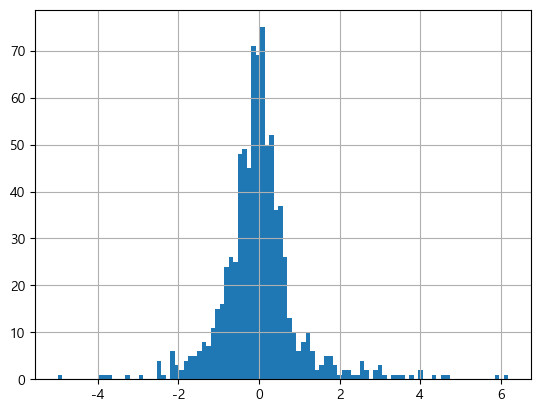

In [68]:
df_od['z_residual'].hist(bins=100)

<Axes: >

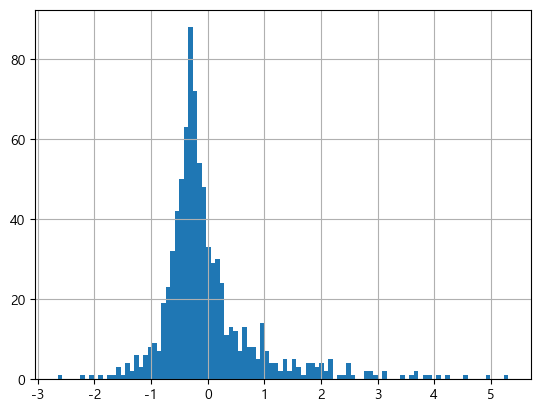

In [69]:
df_od['risk_index'].hist(bins=100)

### 위험그룹분류

In [70]:
df_od["risk_group"] = pd.qcut(
    df_od["risk_index"],
    q=[0, 0.3, 0.7, 1.0],
    labels=["Low", "Mid", "High"]
)

In [71]:
df_od.iloc[:, -6:]

,pred,residual,z_vacancy,z_residual,risk_index,risk_group
0,0.056467,-0.012022,-0.376668,-0.990220,-0.683444,Low
1,-0.001362,0.001362,-0.647484,0.112193,-0.267646,Mid
2,0.035668,0.002794,-0.413124,0.230090,-0.091517,Mid
3,0.017297,-0.005392,-0.574944,-0.444133,-0.509539,Low
4,0.232814,0.025251,0.925000,2.079790,1.502395,High
...,...,...,...,...,...,...
828,0.032268,0.020364,-0.326781,1.677271,0.675245,High
829,0.188839,0.003468,0.524319,0.285672,0.404995,High
830,0.061559,0.006008,-0.235770,0.494881,0.129555,High
831,0.001913,0.004129,-0.610667,0.340087,-0.135290,Mid


In [72]:
df_od.to_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\df_od_label.csv", encoding="utf-8-sig", index_label=False)

## 시각화

In [73]:
import geopandas as gpd

ctprvn = gpd.read_file(r"D:\PP\BC\data\og\ctprvn.shp", encoding='cp949')

# High risk
high = df_od[df_od["risk_group"] == "High"].copy()

# 시도별 High 시장 개수
high_cnt = (
    high.groupby("시도")
        .size()
        .reset_index(name="high_market_cnt")
)

# Mid risk
mid = df_od[df_od["risk_group"] == "Mid"].copy()

# 시도별 Mid 시장 개수
mid_cnt = (
    mid.groupby("시도")
        .size()
        .reset_index(name="mid_market_cnt")
)

# Low risk
low = df_od[df_od["risk_group"] == "Low"].copy()

# 시도별 Low 시장 개수
low_cnt = (
    low.groupby("시도")
        .size()
        .reset_index(name="low_market_cnt")
)

ctprvn = ctprvn.rename(columns={"CTP_KOR_NM": "시도"})
ctprvn_merged = (
    ctprvn
    .merge(high_cnt, on="시도", how="left")
    .merge(mid_cnt, on="시도", how="left")
    .merge(low_cnt, on="시도", how="left")
)

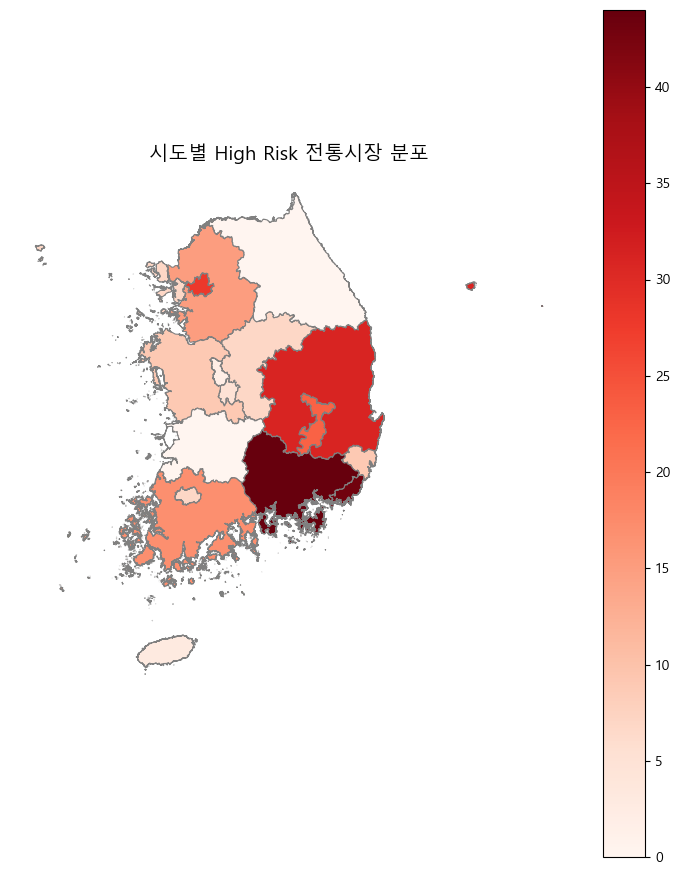

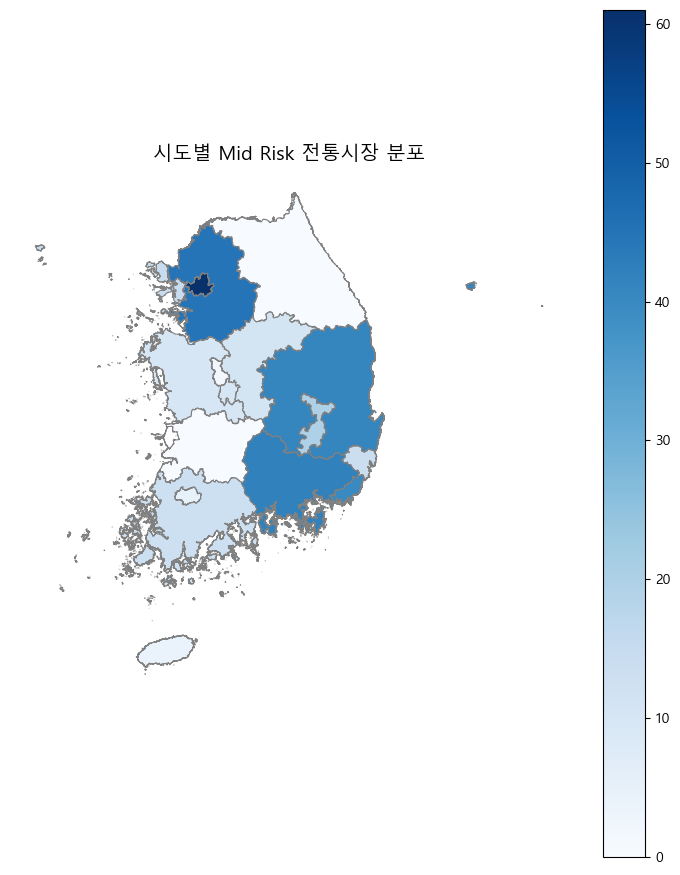

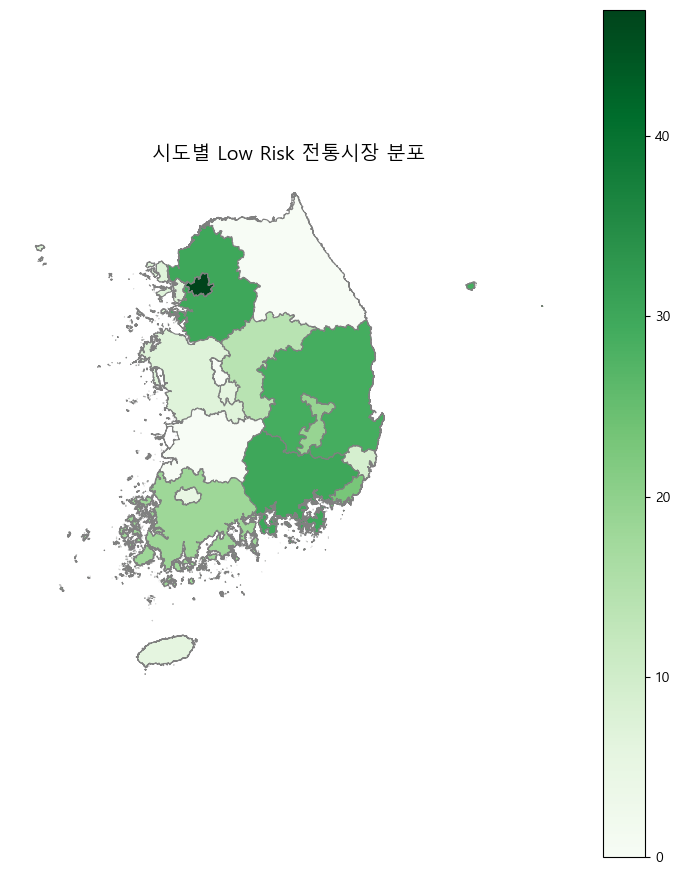

In [74]:
ctprvn_merged["high_market_cnt"] = ctprvn_merged["high_market_cnt"].fillna(0)
ctprvn_merged["mid_market_cnt"] = ctprvn_merged["mid_market_cnt"].fillna(0)
ctprvn_merged["low_market_cnt"] = ctprvn_merged["low_market_cnt"].fillna(0)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(9, 11))

ctprvn_merged.plot(
    column="high_market_cnt",
    cmap="Reds",
    linewidth=0.8,
    edgecolor="gray",
    legend=True,
    ax=ax
)

ax.set_title("시도별 High Risk 전통시장 분포", fontsize=14)
ax.axis("off")

plt.show()

fig, ax = plt.subplots(1, 1, figsize=(9, 11))

ctprvn_merged.plot(
    column="mid_market_cnt",
    cmap="Blues",
    linewidth=0.8,
    edgecolor="gray",
    legend=True,
    ax=ax
)

ax.set_title("시도별 Mid Risk 전통시장 분포", fontsize=14)
ax.axis("off")

plt.show()


fig, ax = plt.subplots(1, 1, figsize=(9, 11))

ctprvn_merged.plot(
    column="low_market_cnt",
    cmap="Greens",
    linewidth=0.8,
    edgecolor="gray",
    legend=True,
    ax=ax
)

ax.set_title("시도별 Low Risk 전통시장 분포", fontsize=14)
ax.axis("off")

plt.show()
